# K-Nearest Neighbor Lab
Read over the sklearn info on [nearest neighbor learners](https://scikit-learn.org/stable/modules/neighbors.html#nearest-neighbors-classification)




In [218]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import numpy as np
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

## 1 K-Nearest Neighbor (KNN) algorithm

### 1.1 (15%) Basic KNN Classification

Learn the [Glass data set](https://archive.ics.uci.edu/dataset/42/glass+identification) using [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier) with default parameters.
- Randomly split your data into train/test.  Anytime we don't tell you specifics (such as what percentage is train vs test) choose your own reasonable values
- Give typical train and test set accuracies after running with different random splits
- Print the output probabilities for a test set (predict_proba)
- Try it with different p values (Minkowskian exponent) and discuss any differences

In [114]:
# Download and prepare dataset
glass_columns = [
    "Id", "RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe", "Type"
]

glass_df = pd.read_csv("glass.data", names=glass_columns, index_col="Id")

X = glass_df.drop(columns=["Type"])
y = glass_df["Type"]
# Display first few rows of features
display(X.head())

# Print class distribution
display(y.value_counts().sort_index())

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
Id,,,,,,,,,
1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0
2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0
3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0
4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0
5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0


Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64

In [115]:
# See how changing p affects the resulting train and test splits
def run_knn_classifier(X, y, test_size=0.2, p=2, random_state = np.random.randint(0,100)):
     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
     KNeighborsModel = KNeighborsClassifier(p=p)
     KNeighborsModel.fit(X_train, np.ravel(y_train))
     train_acc = KNeighborsModel.score(X_train, np.ravel(y_train))
     test_acc = KNeighborsModel.score(X_test, np.ravel(y_test))
     output_probs = KNeighborsModel.predict_proba(X_test)
     return KNeighborsModel, train_acc, test_acc, output_probs, X_test, y_test

results = []
for p in [1,2,3]:
    total_train_acc = []
    total_test_acc = []
    for i in range(30):
        model, train_acc, test_acc, output_probs, X_test, y_test = run_knn_classifier(X, y, test_size = 0.2, p = p, random_state = i)
        total_train_acc.append(train_acc)
        total_test_acc.append(test_acc)
    results.append({"p": p, "train_acc": np.mean(total_train_acc), "test_acc": np.mean(total_test_acc)})

results_df = pd.DataFrame(results)
print("Accuracies of using different p values, averaging over 30 seeds")
display(results_df)

Accuracies of using different p values, averaging over 30 seeds


,p,train_acc,test_acc
0,1,0.791033,0.669767
1,2,0.761988,0.644186
2,3,0.761988,0.631783


In [116]:
# Analyze output probabilities
for p in [1,2,3]:
    model, train_acc, test_acc, output_probs, X_test, y_test = run_knn_classifier(X, y, test_size = 0.2, p = p, random_state = 123)
    output_probs_df = pd.DataFrame(output_probs, columns=[f"class_{c}" for c in model.classes_])
    predictions = model.predict(X_test)
    output_probs_df.insert(0, "predicted_label", predictions)
    output_probs_df.insert(0, "true_label", y_test.values)
    print(f"Output probabilities for p = {p}")
    display(output_probs_df.iloc[:10])

Output probabilities for p = 1


,true_label,predicted_label,class_1,class_2,class_3,class_5,class_6,class_7
0,5,5,0.0,0.2,0.0,0.8,0.0,0.0
1,7,7,0.0,0.0,0.0,0.0,0.0,1.0
2,1,1,1.0,0.0,0.0,0.0,0.0,0.0
3,2,5,0.0,0.0,0.2,0.4,0.4,0.0
4,2,2,0.2,0.8,0.0,0.0,0.0,0.0
5,3,1,0.6,0.4,0.0,0.0,0.0,0.0
6,7,7,0.0,0.0,0.0,0.0,0.0,1.0
7,2,2,0.2,0.8,0.0,0.0,0.0,0.0
8,7,7,0.2,0.0,0.0,0.0,0.0,0.8
9,2,2,0.0,1.0,0.0,0.0,0.0,0.0


Output probabilities for p = 2


,true_label,predicted_label,class_1,class_2,class_3,class_5,class_6,class_7
0,5,5,0.0,0.2,0.0,0.8,0.0,0.0
1,7,7,0.0,0.0,0.0,0.0,0.0,1.0
2,1,1,1.0,0.0,0.0,0.0,0.0,0.0
3,2,5,0.2,0.0,0.0,0.4,0.4,0.0
4,2,2,0.2,0.8,0.0,0.0,0.0,0.0
5,3,2,0.4,0.6,0.0,0.0,0.0,0.0
6,7,7,0.0,0.0,0.0,0.0,0.0,1.0
7,2,2,0.4,0.6,0.0,0.0,0.0,0.0
8,7,1,0.4,0.0,0.2,0.0,0.2,0.2
9,2,2,0.0,1.0,0.0,0.0,0.0,0.0


Output probabilities for p = 3


,true_label,predicted_label,class_1,class_2,class_3,class_5,class_6,class_7
0,5,5,0.0,0.2,0.0,0.8,0.0,0.0
1,7,7,0.0,0.0,0.0,0.0,0.0,1.0
2,1,1,1.0,0.0,0.0,0.0,0.0,0.0
3,2,5,0.2,0.0,0.0,0.4,0.4,0.0
4,2,2,0.2,0.8,0.0,0.0,0.0,0.0
5,3,2,0.4,0.6,0.0,0.0,0.0,0.0
6,7,7,0.0,0.0,0.0,0.0,0.0,1.0
7,2,2,0.4,0.6,0.0,0.0,0.0,0.0
8,7,1,0.4,0.2,0.2,0.0,0.0,0.2
9,2,2,0.0,1.0,0.0,0.0,0.0,0.0


#### Discussion
What were your accuracies or output probabilities and how did different hyperparameter values affect the outcome? Discuss the differences you see.

**The accuracies with a test_size of 0.2 at different random splits averaged about 0.77 for the train accuracy and 0.65 for the test accuracy.  Averaging over several different random seeds, I found that setting the Minkowskian exponent to 1 usually resulted in slightly higher train and test accuracies. Since both the train and test accuracies increased, it is fairly safe to assume that the model was not better simply by overfitting, but rather resulted in a better model.  With the output probabilities, I created a dataframe to show the probabilities alongside predicted labels and true labels to see model performance.  In the end, however, I noticed that very few values would change with each change to the Minkowskian exponent, but that was to be expected considering that the train and test accuracies between different p-values only had a 2 or 3 percent difference.**

## 2 KNN Classification with normalization and distance weighting

Use the [magic telescope](https://axon.cs.byu.edu/data/uci_class/MagicTelescope.arff) dataset

### 2.1 (5%) - Without Normalization or Distance Weighting
- Do random 80/20 train/test splits each time
- Run with k=3 and *without* distance weighting and *without* normalization
- Show train and test set accuracy

In [ ]:
# Load and explore the dataset
magic_telescope, meta = arff.loadarff("magic_telescope_train.arff")

# Convert the record array to a pandas DataFrame
magic_telescope_df = pd.DataFrame(magic_telescope)
X = magic_telescope_df.drop(columns=["class"])
y = magic_telescope_df["class"].str.decode('utf-8')

# Display first few rows of features
display(X.head())

# Print class distribution
display(y.value_counts().sort_index())


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
0,22.7815,14.9526,2.4362,0.4982,0.2509,-14.2836,-9.3635,13.0939,3.0779,141.5620
1,40.6756,15.5940,2.7447,0.2772,0.1449,19.6226,9.0297,7.4157,15.4260,193.2340
2,12.8427,11.3821,2.1255,0.7191,0.4232,-14.9637,8.5891,6.9418,82.4198,183.9790
3,77.0262,32.2880,3.3502,0.3152,0.1868,-28.6712,-35.9464,-31.4001,0.8940,357.0440
4,27.5146,11.2114,2.6637,0.4643,0.2687,42.4467,33.0422,-6.3980,50.3004,239.8878


class
g    7971
h    4383
Name: count, dtype: int64

In [118]:
# Train/Predict without normalization or distance weighting
train_accuracies = []
test_accuracies = []
for n in range(20):
    # Set up data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=n)

    # Fit model without normalization or distance weighting
    KNeighborsModel = KNeighborsClassifier(n_neighbors=3)
    KNeighborsModel.fit(X_train, y_train)
    train_accuracies.append(KNeighborsModel.score(X_train, y_train))
    test_accuracies.append(KNeighborsModel.score(X_test, y_test))

print(f"Average train and test accuracies averaged over 20 seeds")
print("Train Accuracy: " + str(np.mean(train_accuracies)))
print("Test Accuracy: " + str(np.mean(test_accuracies)))

Average train and test accuracies averaged over 20 seeds
Train Accuracy: 0.8787615096630578
Test Accuracy: 0.7883650343990286


#### Discussion
What did you observe in your results?

**With k=3 and without performing any normalization or distance weighting, I get an average train accuracy of 87.88% and an average test accuracy of 78.84%, with each being the average over 20 different seeds.  With the test accuracy being about 10% lower than the train accuracy, I can assume that there is likely some overfitting occuring.**

### 2.2 (10%) With Normalization
- Try it with k=3 without distance weighting but *with* normalization of input features.  You may use any reasonable normalization approach (e.g. standard min-max normalization between 0-1, z-transform, etc.)

In [119]:
# Train/Predict with normalization but without distance weighting
train_accuracies = []
test_accuracies = []
for n in range(20):
    # Set up data and normalize inputs
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=n)
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scale = scaler.transform(X_train)
    X_test_scale = scaler.transform(X_test)
    
    # Create and fit model
    KNeighborsModel = KNeighborsClassifier(n_neighbors=3)
    KNeighborsModel.fit(X_train_scale, y_train)
    train_accuracies.append(KNeighborsModel.score(X_train_scale, y_train))
    test_accuracies.append(KNeighborsModel.score(X_test_scale, y_test))

print(f"Average train and test accuracies averaged over 20 seeds")
print("Train Accuracy: " + str(np.mean(train_accuracies)))
print("Test Accuracy: " + str(np.mean(test_accuracies)))

Average train and test accuracies averaged over 20 seeds
Train Accuracy: 0.897728422543762
Test Accuracy: 0.8186564144071227


#### Discussion
Discuss the results of using normalized data vs. unnormalized data

**With the addition of normalizing the data and running it over the same 20 seeds, I see the train accuracy increase from 87.77% to 89.77% and the test accuracy increase from 78.84% to 81.87%. With these increases in both train and test accuracies, I can see that normalizing the input features definitely improves the model. Since the test accuracy improved more than the train accuracy improved, I can see that normalizing the input features also helped the model generalize better.**

### 2.3 (10%) With Distance Weighting
- Try it with k=3 and with distance weighting *and* normalization

In [120]:
# Train/Predict with normalization and distance weighting
train_accuracies = []
test_accuracies = []
for n in range(20):
    # Set up data and normalize inputs
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=n)
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scale = scaler.transform(X_train)
    X_test_scale = scaler.transform(X_test)
    
    # Create and fit model
    KNeighborsModel = KNeighborsClassifier(n_neighbors=3, weights = "distance")
    KNeighborsModel.fit(X_train_scale, y_train)
    train_accuracies.append(KNeighborsModel.score(X_train_scale, y_train))
    test_accuracies.append(KNeighborsModel.score(X_test_scale, y_test))

print(f"Average train and test accuracies averaged over 20 seeds")
print("Train Accuracy: " + str(np.mean(train_accuracies)))
print("Test Accuracy: " + str(np.mean(test_accuracies)))

Average train and test accuracies averaged over 20 seeds
Train Accuracy: 1.0
Test Accuracy: 0.8211048158640228


#### Discussion
Comparison and discuss the differences you see with distance weighting and normalization vs without.

**For the model with normalization and distance weighting and averaging over 20 seeds, I see that the train accuracy is 100% and the test accuracy is 82.11%.  This model performs the best overall compared to the model without normalizing inputs nor distance weighting and the model that normalized imports without distance weighting.  We see that there is some overfitting with the train accuracy at 100% but since this model also has the highest test accuracy, it is the best overall model of the three tested.**

### 2.4 (10%) Different k Values
- Using your normalized data with distance weighting, create one graph with classification accuracy on the test set on the y-axis and k values on the x-axis.
- Use values of k from 1 to 15.  Use the same train/test split for each.

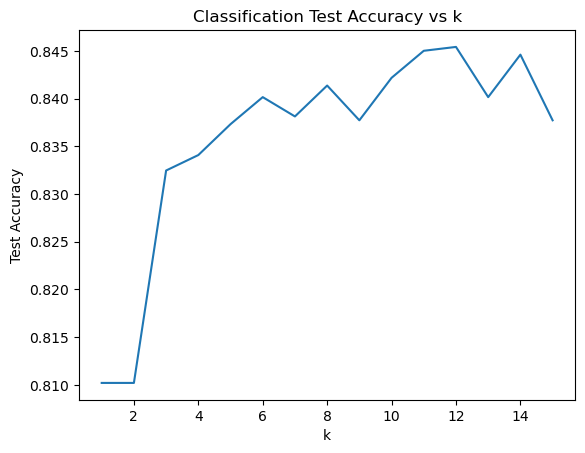

In [121]:
# Calculate and Graph classification accuracy vs k values
k_values = np.arange(1, 16)
test_accuracies = []

# Loop over k values
for k in k_values:
  KNeighborsModel = KNeighborsClassifier(n_neighbors=k, weights='distance')
  KNeighborsModel.fit(X_train_scale, y_train)
  test_accuracies.append(KNeighborsModel.score(X_test_scale, y_test))

# Plot it
plt.plot(k_values, test_accuracies)
plt.title('Classification Test Accuracy vs k')
plt.xlabel('k')
plt.ylabel('Test Accuracy')
plt.show()


#### Discussion
How do the k values affect your results?

**From the graph above, I see that as k increases, the test accuracy increases.  This is true until when k reaches about 11 or 12, after which the test accuracy remains the same or worsens as k increases.  The difference in the range of the test accuracies with different k values is only about 3.5%, so overall, changing k does not make a huge difference overall.**

## 3 KNN Regression with normalization and distance weighting

Use the [sklean KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor) on the [housing price prediction](https://axon.cs.byu.edu/data/uci_regression/housing.arff) problem.  
### 3.1 (5%) Ethical Data
Note this data set has an example of an inappropriate input feature which we discussed.  State which feature is inappropriate and discuss why.

In [122]:
# Load and explore data
housing, meta = arff.loadarff("housing_train.arff")
housing_df = pd.DataFrame(housing)
# Removing "B" column since it is unethical
X = housing_df.drop(columns=["MEDV", "B", "CHAS"])
display(X)
y = housing_df["MEDV"]
display(y)


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT
0,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14
1,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03
2,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94
3,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33
4,0.02985,0.0,2.18,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,5.21
...,...,...,...,...,...,...,...,...,...,...,...
450,0.06263,0.0,11.93,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,9.67
451,0.04527,0.0,11.93,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,9.08
452,0.06076,0.0,11.93,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,5.64
453,0.10959,0.0,11.93,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,6.48


0      21.6
1      34.7
2      33.4
3      36.2
4      28.7
       ... 
450    22.4
451    20.6
452    23.9
453    22.0
454    11.9
Name: MEDV, Length: 455, dtype: float64

#### Discussion
Discuss the innapropriate feature. Which one and why?

**In this dataset, the input feature "B" is inappropriate because it represents the proportion of blacks by town, which is creating an inherent prejudice against blacks. This is unethical and should be avoided in order to get a more meaningful result. Additionally, the "CHAS" input feature is a categorical variable that must be changed using one-hot-encoding in order for it to be accurately used in a KNeighborsRegressor model.**

### 3.2 (15%) - KNN Regression
- Do random 80/20 train/test splits each time
- Run with k=3
- Print the score (coefficient of determination) and Mean Absolute Error (MAE) for the train and test set for the cases of
  - No input normalization and no distance weighting
  - Normalization and no distance weighting
  - Normalization and distance weighting
- Normalize inputs features where needed but do not normalize the output

In [123]:
# Learn and experiment with housing price prediction data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# No input normalization and no distance weighting
print("No input normalization and no distance weighting")
KNeighborsModel = KNeighborsRegressor(n_neighbors=3)
KNeighborsModel.fit(X_train, np.ravel(y_train))
print("Train Score: " + str(KNeighborsModel.score(X_train, np.ravel(y_train))))
print("Train MAE: " + str(np.mean(np.abs(y_train - KNeighborsModel.predict(X_train)))))
print("Test Score: " + str(KNeighborsModel.score(X_test, np.ravel(y_test))))
print("Test MAE: " + str(np.mean(np.abs(y_test - KNeighborsModel.predict(X_test)))))

# Normalization and no distance weighting
print("\nNormalization and no distance weighting")
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scale = scaler.transform(X_train)
X_test_scale = scaler.transform(X_test)
KNeighborsModel = KNeighborsRegressor(n_neighbors=3)
KNeighborsModel.fit(X_train_scale, np.ravel(y_train))
print("Train Score: " + str(KNeighborsModel.score(X_train_scale, np.ravel(y_train))))
print("Train MAE: " + str(np.mean(np.abs(y_train - KNeighborsModel.predict(X_train_scale)))))
print("Test Score: " + str(KNeighborsModel.score(X_test_scale, np.ravel(y_test))))
print("Test MAE: " + str(np.mean(np.abs(y_test - KNeighborsModel.predict(X_test_scale)))))

# Normalization and distance weighting
print("\nNormalization and distance weighting")
KNeighborsModel = KNeighborsRegressor(n_neighbors=3, weights='distance')
KNeighborsModel.fit(X_train_scale, np.ravel(y_train))
print("Train Score: " + str(KNeighborsModel.score(X_train_scale, np.ravel(y_train))))
print("Train MAE: " + str(np.mean(np.abs(y_train - KNeighborsModel.predict(X_train_scale)))))
print("Test Score: " + str(KNeighborsModel.score(X_test_scale, np.ravel(y_test))))
print("Test MAE: " + str(np.mean(np.abs(y_test - KNeighborsModel.predict(X_test_scale)))))

No input normalization and no distance weighting
Train Score: 0.7837625123589659
Train MAE: 2.79459706959707
Test Score: 0.5490294244989662
Test MAE: 4.243956043956044

Normalization and no distance weighting
Train Score: 0.9169141625939237
Train MAE: 1.7735347985347985
Test Score: 0.7776969533410888
Test MAE: 3.002197802197802

Normalization and distance weighting
Train Score: 1.0
Train MAE: 0.0
Test Score: 0.7935315311590639
Test MAE: 2.900290360641348


#### Discussion
Discuss your results. How did the hyperparameters affect your results? Discuss each one and combinations of each.

**I saw in my results that adding in normalization and distance weighting improved model performance.  The initial model with no normalization and no distance weighting had a much higher train score than test score, indicating some potential overfitting to the train data.  When adding normalizaiton on the inputs, both the train and test scores increased, indicating a positive effect from normalization.  Adding distance weighting onto that made the model perform perfect on the train data with only slight improvement to the test data. Since the final model with normalization and distance weighting had the highest test score and lowest test MSE, it is the best model of the three.**

### 3.3 (10%)  Different k Values
- Using housing with normalized data and distance weighting, create one graph with MAE on the test set on the y-axis and k values on the x-axis
- Use values of k from 1 to 15.  Use the same train/test split for each.

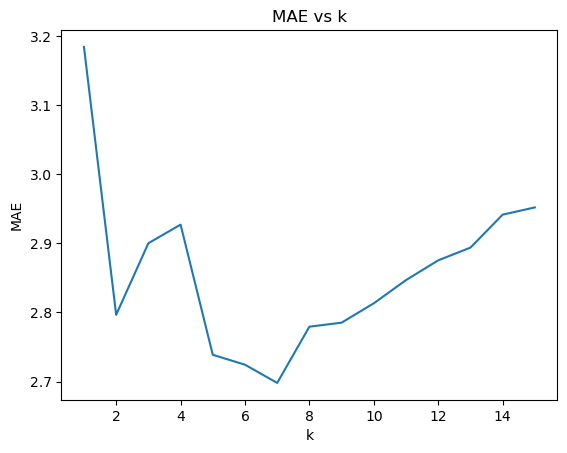

In [124]:
# Learn and graph for different k values
k_values = np.arange(1, 16)
test_mae = []
for k in k_values:
  KNeighborsModel = KNeighborsRegressor(n_neighbors=k, weights='distance')
  KNeighborsModel.fit(X_train_scale, np.ravel(y_train))
  test_mae.append(np.mean(np.abs(y_test - KNeighborsModel.predict(X_test_scale))))

plt.plot(k_values, test_mae)
plt.title('MAE vs k')
plt.xlabel('k')
plt.ylabel('MAE')
plt.show()

#### Discussion
How did the k values affect your results for this dataset? How does that compare to your previous work in this lab?

**For this dataset, increasing k decreased the MAE rapidly until k = 3, after which it went up for k = 4 and then decreases again until k = 7. Further increases to k only increases the MSE slightly. This is different to what was seen with the magic telescope data because in those results we saw that high k values were beneficial and there was not a clear best choice for k.  For the housing dataset, we see a clear best value for k and increasing k further actually makes the model worse. For both cases, increasing k to at least 3 or 4 is clearly beneficial for the model.**

## 4. (20%) KNN with nominal and real data

- Use the [lymph dataset](https://axon.cs.byu.edu/data/uci_class/lymph.arff)
- Use a 80/20 split of the data for the training/test set
- This dataset has both continuous and nominal attributes
- Implement a distance metric which uses Euclidean distance for continuous features and 0/1 distance for nominal. Hints:
    - Write your own distance function (e.g. mydist) and use clf = KNeighborsClassifier(metric=mydist)
    - Change the nominal features in the data set to integer values since KNeighborsClassifier expects numeric features. I used Label_Encoder on the nominal features.
    - Keep a list of which features are nominal which mydist can use to decide which distance measure to use
    - There was an occasional bug in SK version 1.3.0 ("Flags object has no attribute 'c_contiguous'") that went away when I upgraded to the lastest SK version 1.3.1
- Use your own choice for k and other parameters

In [125]:
# Download and prepare dataset
lymph_columns = [
    "class", "lymphatics", "block_of_affere", "bl_of_lymph_c", "bl_of_lymph_s",
    "by_pass", "extravasates", "regeneration_of", "early_uptake_in", "lymph_node_dimin",
    "lymph_node_enlar", "changes_in_lym", "defect_in_node", "changes_in_node", "change_in_stru",
    "special_forms", "dislocation_of", "exclusion_of_no", "no_of_nodes_in"]

lymph_df = pd.read_csv("lymphography.data", names=lymph_columns)
X = lymph_df.drop(columns=["class"])
y = lymph_df["class"]
# Display first few rows of features
display(X.head())

# Print class distribution
display(y.value_counts().sort_index())

# Print dtypes of all x values
print(X.dtypes)

,lymphatics,block_of_affere,bl_of_lymph_c,bl_of_lymph_s,by_pass,extravasates,regeneration_of,early_uptake_in,lymph_node_dimin,lymph_node_enlar,changes_in_lym,defect_in_node,changes_in_node,change_in_stru,special_forms,dislocation_of,exclusion_of_no,no_of_nodes_in
0,4,2,1,1,1,1,1,2,1,2,2,2,4,8,1,1,2,2
1,3,2,1,1,2,2,1,2,1,3,3,2,3,4,2,2,2,2
2,3,2,2,2,2,2,2,2,1,4,3,3,4,8,3,2,2,7
3,3,1,1,1,1,2,1,2,1,3,3,4,4,4,3,1,2,6
4,3,1,1,1,1,1,1,1,1,2,2,4,3,5,1,2,2,1


class
1     2
2    81
3    61
4     4
Name: count, dtype: int64

lymphatics          int64
block_of_affere     int64
bl_of_lymph_c       int64
bl_of_lymph_s       int64
by_pass             int64
extravasates        int64
regeneration_of     int64
early_uptake_in     int64
lymph_node_dimin    int64
lymph_node_enlar    int64
changes_in_lym      int64
defect_in_node      int64
changes_in_node     int64
change_in_stru      int64
special_forms       int64
dislocation_of      int64
exclusion_of_no     int64
no_of_nodes_in      int64
dtype: object


In [126]:
# Train/Predict lymph with your own distance metric
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=np.random.randint(0,100))

# Function that maps distances to 0 or 1. Since all features are nominal, we map all features to 0 or 1 with this function
def mydist(first_point, second_point):
  return np.sum(first_point != second_point)

KNeighborsModel = KNeighborsClassifier(n_neighbors=3, metric = mydist)
KNeighborsModel.fit(X_train, np.ravel(y_train))
print("Train Accuracy: " + str(KNeighborsModel.score(X_train, np.ravel(y_train))))
print("Test Accuracy: " + str(KNeighborsModel.score(X_test, np.ravel(y_test))))

Train Accuracy: 0.9152542372881356
Test Accuracy: 0.7333333333333333


#### Discussion
Explain your distance metric and discuss your results

**Since all features were nominal (as seen by the print statement above showing that all are int64 dtypes), my function compares each feature of two different points and adds one to the distance for each feature that does not match.  This results in the distance between two points being the sum of the number of features that do not match.  The results were fairly good with a train accuracy of around 90% and a test accuracy of around 80% with some definite variation with different seeds.**

## 5. (Optional 15% extra credit) Code up your own KNN Learner
Below is a scaffold you could use if you want. Requirements for this task:
- Your model should support the methods shown in the example scaffold below
- Use Euclidean distance to decide closest neighbors
- Implement both the classification and regression versions
- Include optional distance weighting for both algorithms
- Run your algorithm on the magic telescope and housing data sets above and discuss and compare your results

In [223]:
from sklearn.base import BaseEstimator, ClassifierMixin

class KNNClassifier(BaseEstimator,ClassifierMixin):
    def __init__(self, columntype=[], weight_type='inverse_distance', n_neighbors = 5): ## add parameters here
        """
        Args:
            columntype for each column tells you if continues[real] or if nominal[categoritcal].
            weight_type: inverse_distance voting or if non distance weighting. Options = ["no_weight","inverse_distance"]
        """
        self.columntype = columntype #Note This won't be needed until part 5
        self.weight_type = weight_type
        self.n_neighbors = n_neighbors

    def fit(self, data, labels):
        """ Fit the data; run the algorithm (for this lab really just saves the data :D)
        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
            y (array-like): A 2D numpy array with the training targets
        Returns:
            self: this allows this to be chained, e.g. model.fit(X,y).predict(X_test)
        """
        self.data_trained_on = data
        self.labels_of_data_trained_on = labels
        return self

    def predict(self, X):
        """ Predict all classes for a dataset X
        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
        Returns:
            array, shape (n_samples,)
                Predicted target values per element in X.
        """
        results = []
        # Iterate through all inputs
        for new_point_index in range(len(X)):
            # Get all distances from data in training set
            distances = {}
            for data_point_index in range(len(self.data_trained_on)):
                distance = 0
                # Iterate through features to find distance between the two points
                for i, feature in enumerate(X.iloc[new_point_index]):
                    train_feature = self.data_trained_on.iloc[data_point_index, i]
                    if isinstance(feature, (float, int)):
                        distance += np.linalg.norm(feature - train_feature)
                    else:
                        distance += (feature != train_feature)
                distances[data_point_index] = distance
            nearest_neighbors = sorted(distances.items(), key=lambda x: x[1])[:self.n_neighbors]
            # Change logic if categorical vs regression
            if isinstance(self.labels_of_data_trained_on.iloc[0], str):
                # Add weights if needed
                if self.weight_type == "inverse_distance":
                    predicted_labels = self.labels_of_data_trained_on.iloc[[x[0] for x in nearest_neighbors]]
                    predicted_distances = [x[1] for x in nearest_neighbors]
                    classes = {}
                    for i, label in enumerate(predicted_labels):
                        weight = 1 / (predicted_distances[i] + 1e-8)
                        classes[label] = classes.get(label, 0) + weight
                    results.append(max(classes.items(), key=lambda x: x[1])[0])
                else:
                    predicted_labels = self.labels_of_data_trained_on.iloc[[x[0] for x in nearest_neighbors]]
                    results.append(predicted_labels.mode().item())
            else:
                # Add weights if needed
                if self.weight_type == "inverse_distance":
                    predicted_values = self.labels_of_data_trained_on.iloc[[x[0] for x in nearest_neighbors]]
                    predicted_distances = [x[1] for x in nearest_neighbors]
                    weights = [1 / (d + 1e-8) for d in predicted_distances]
                    weighted_sum = sum(w * y for w, y in zip(weights, predicted_values))
                    weight_total = sum(weights)
                    results.append(weighted_sum / weight_total)
                else:
                    predicted_labels = self.labels_of_data_trained_on.iloc[[x[0] for x in nearest_neighbors]]
                    results.append(np.mean(predicted_labels).item())
        return results

    #Returns the Mean score given input data and labels
    def score(self, X, y):
        """ Return accuracy of model on a given dataset. Must implement own score function.
        Args:
            X (array-like): A 2D numpy array with data, excluding targets
            y (array-like): A 2D numpy array with targets
        Returns:
            score : float
                Mean accuracy of self.predict(X) wrt. y.
        """
        predictions = self.predict(X)
        if isinstance(self.labels_of_data_trained_on.iloc[0], str):
            score = np.mean(predictions == y)
        else:
            score = r2_score(y, predictions)
        return score

In [245]:
# Load magic_telescope data
magic_telescope, meta = arff.loadarff("magic_telescope_train.arff")

# Convert the record array to a pandas DataFrame
magic_telescope_df = pd.DataFrame(magic_telescope)
# To save time, I only train on 500 points and test on 100 points

X = magic_telescope_df.drop(columns=["class"]).loc[:501]
y = magic_telescope_df["class"].str.decode('utf-8').loc[:501]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1234)

# My method, no_weight
classifier_no_weight = KNNClassifier(weight_type="no_weight")
classifier_no_weight.fit(X_train, y_train)
predictions = classifier_no_weight.predict(X.loc[:4])
print("Predictions on model: ", predictions)
print("Score with no distance weighting: ", classifier_no_weight.score(X_test, y_test))

# My method, with weight
classifier_inverse_weight = KNNClassifier(weight_type="inverse_distance")
classifier_inverse_weight.fit(X_train, y_train)
predictions = classifier_inverse_weight.predict(X.loc[:4])
print("Predictions on model: ", predictions)
print("Score with inverse distance weighting: ", classifier_inverse_weight.score(X_test, y_test))

# Built in method, no_weight
classifier_no_weight = KNeighborsClassifier()
classifier_no_weight.fit(X_train, y_train)
predictions = classifier_no_weight.predict(X.loc[:4])
print("Predictions on built in model with no distance weighting: ", predictions)
print("Score with no distance weighting: ", classifier_no_weight.score(X_test, y_test))

# Built in method, with weight
classifier_inverse_weight = KNeighborsClassifier(weights="distance")
classifier_inverse_weight.fit(X_train, y_train)
predictions = classifier_inverse_weight.predict(X.loc[:4])
print("Predictions on built in model with inverse distance weighting: ", predictions)
print("Score with inverse distance weighting: ", classifier_inverse_weight.score(X_test, y_test))

Predictions on model:  ['g', 'g', 'h', 'g', 'h']
Score with no distance weighting:  0.7425742574257426
Predictions on model:  ['g', 'g', 'g', 'g', 'h']
Score with inverse distance weighting:  0.7524752475247525
Predictions on built in model with no distance weighting:  ['g' 'g' 'g' 'g' 'h']
Score with no distance weighting:  0.7128712871287128
Predictions on built in model with inverse distance weighting:  ['g' 'g' 'g' 'g' 'h']
Score with inverse distance weighting:  0.7128712871287128


In [ ]:
# Load housing data
housing, meta = arff.loadarff("housing_train.arff")

# Convert the record array to a pandas DataFrame
housing_df = pd.DataFrame(housing)
# To save time, I only train on 500 points and test on 100 points
X = housing_df.drop(columns=["MEDV", "B", "CHAS"]).loc[:501]
y = housing_df["MEDV"].loc[:501]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1234)

# My method, no_weight
regressor_no_weight = KNNClassifier(weight_type="no_weight")
regressor_no_weight.fit(X_train, y_train)
predictions = regressor_no_weight.predict(X.loc[:4])
print("Predictions on model: ", predictions)
print("Score with no distance weighting: ", regressor_no_weight.score(X_test, y_test))

# My method, with weight
regressor_inverse_weight = KNNClassifier(weight_type="inverse_distance")
regressor_inverse_weight.fit(X_train, y_train)
predictions = regressor_inverse_weight.predict(X.loc[:4])
print("Predictions on model: ", predictions)
print("Score with inverse distance weighting: ", regressor_inverse_weight.score(X_test, y_test))

# Built in method, no_weight
regressor_no_weight = KNeighborsRegressor()
regressor_no_weight.fit(X_train, y_train)
predictions = regressor_no_weight.predict(X.loc[:4])
print("Predictions on built in model with no distance weighting: ", predictions)
print("Score with no distance weighting: ", regressor_no_weight.score(X_test, y_test))

# Built in method, with weight
regressor_inverse_weight = KNeighborsRegressor(weights="distance")
regressor_inverse_weight.fit(X_train, y_train)
predictions = regressor_inverse_weight.predict(X.loc[:4])
print("Predictions on built in model with inverse distance weighting: ", predictions)
print("Score with inverse distance weighting: ", regressor_inverse_weight.score(X_test, y_test))


Predictions on model:  [24.76, 26.48, 27.9, 27.160000000000004, 27.160000000000004]
Score with no distance weighting:  0.6734027927200361
Predictions on model:  [25.323566382813347, 34.69999998530297, 33.399999986017356, 36.199999967937195, 28.700000007030646]
Score with inverse distance weighting:  0.6942632801424067
Predictions on built in model with no distance weighting:  [23.38 25.24 26.28 27.16 27.16]
Score with no distance weighting:  0.6069707950258234
Predictions on built in model with inverse distance weighting:  [23.3745064 34.7       33.4       36.2       28.7      ]
Score with inverse distance weighting:  0.6333036957320282


**Implementing my own KNN Learner took much longer than I anticipated, but I also learned a lot in the process. I got some very intriguing results, with my classification and regression models receiving higher scores than the built in KNN methods from scikit-learn. My guess is that something isn't completely right with my implementation, leading to skewed results, but it is hard to determine what that might be. I do know that it is very close though because the predictions, especially with the KNeighborsRegressor is very close to my implementation predictions. It is of note that my methods run significantly slower than the built in methods. The hardest part for me with implementation was dealing with the database objects and knowing how to properly take a subset of them to perform the proper calculations. It was also difficult to think about the differences needed between a classification knn and a regressor knn.**